In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import importlib.metadata

try:
    importlib.metadata.version('venn')
    importlib.metadata.version('pyyaml')
    importlib.metadata.version('scikit-learn')
except importlib.metadata.PackageNotFoundError:
    print("Installing missing packages...")
    ! python -m pip install venn pyyaml scikit-learn

# Get max curated data

In [3]:
import requests
from yaml import safe_load
import numpy as np
import re

activities = ["Ki", "IC50"]
data_url = "https://raw.githubusercontent.com/rinikerlab/overlapping_assays/refs/heads/main/datasets/{dataset}_datasets.yaml"


command_str = (
    "capricho get -tids {targets} -chiral -duchi -reqdoc "
    "-cure --max-assay-size 100 --min-assay-size 20 -smr -calc -c 9,8,7 "
    "-biotype {activity}"  # -idcols assay_type
)

## Ki

In [4]:
result = requests.get(data_url.format(dataset=activities[0]))
result.raise_for_status()

datasets = safe_load(result.content)

ki_targets = []
keys = datasets["sources"].keys()
for key in keys:
    ki_targets.append(datasets["sources"][key]["description"])

ki_targets = np.unique(ki_targets).tolist()
ki_targets = [re.compile("(CHEMBL\d+)").search(t).group(1) for t in ki_targets]
command = (
    command_str.format(targets=",".join(ki_targets), activity=activities[0])
    + " -o curated-Ki-NoAssayOverlap.csv"
)
print(command)

capricho get -tids CHEMBL205,CHEMBL214,CHEMBL217,CHEMBL218,CHEMBL224,CHEMBL226,CHEMBL228,CHEMBL233,CHEMBL234,CHEMBL237,CHEMBL243,CHEMBL244,CHEMBL251,CHEMBL253,CHEMBL255,CHEMBL256,CHEMBL259,CHEMBL261,CHEMBL264,CHEMBL313,CHEMBL3155,CHEMBL3242,CHEMBL3371,CHEMBL344,CHEMBL3594,CHEMBL4153 -chiral -duchi -reqdoc -cure --max-assay-size 100 --min-assay-size 20 -smr -calc -c 9,8,7 -biotype Ki -o curated-Ki-NoAssayOverlap.csv


## IC50

In [5]:
result = requests.get(data_url.format(dataset=activities[1]))
result.raise_for_status()

datasets = safe_load(result.content)

ic50_targets = []
keys = datasets["sources"].keys()
for key in keys:
    ic50_targets.append(datasets["sources"][key]["description"])

ic50_targets = np.unique(ic50_targets).tolist()
ic50_targets = [re.compile("(CHEMBL\d+)").search(t).group(1) for t in ic50_targets]
command = (
    command_str.format(targets=",".join(ic50_targets), activity=activities[1])
    + " -o curated-IC50-NoAssayOverlap.csv"
)
print(command)

capricho get -tids CHEMBL1163125,CHEMBL1741186,CHEMBL1865,CHEMBL1974,CHEMBL2039,CHEMBL203,CHEMBL206,CHEMBL2148,CHEMBL220,CHEMBL222,CHEMBL228,CHEMBL2409,CHEMBL240,CHEMBL243,CHEMBL247,CHEMBL260,CHEMBL262,CHEMBL279,CHEMBL284,CHEMBL2971,CHEMBL3105,CHEMBL3130,CHEMBL3229,CHEMBL325,CHEMBL3267,CHEMBL344,CHEMBL3471,CHEMBL3717,CHEMBL4005,CHEMBL4015,CHEMBL4078,CHEMBL4235,CHEMBL4296,CHEMBL4685,CHEMBL4794,CHEMBL4822,CHEMBL5145,CHEMBL5251,CHEMBL5763 -chiral -duchi -reqdoc -cure --max-assay-size 100 --min-assay-size 20 -smr -calc -c 9,8,7 -biotype IC50 -o curated-IC50-NoAssayOverlap.csv


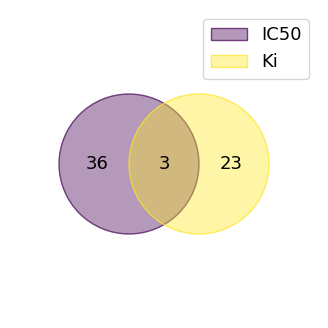

In [6]:
from venn import venn

venn_dict = {"IC50": set(ic50_targets), "Ki": set(ki_targets)}
venn(venn_dict, figsize=(4, 4))

plt.show()

# IC50 overlap

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Import from Capricho analysis module
from Capricho.analysis import (
    ProcessingComment,
    explode_assay_comparability,
    get_all_comments,
    plot_multi_panel_comparability,
    plot_subset,
)

In [8]:
df = pd.read_csv("curated_data/curated-IC50-NoAssayOverlap.csv", engine="pyarrow")
subset = df.query('processed_smiles.str.contains("|", regex=False)').assign(repeat=lambda x: range(len(x)))
subset.shape

(46780, 37)

In [9]:
df.data_processing_comment.apply(
    lambda x: x.split("|") if isinstance(x, str) else []
).explode().value_counts()

data_processing_comment
                                                                                    75892
pChEMBL Duplication Across Documents                                                53265
Salt/solvent removed                                                                 6272
Calculated pChEMBL                                                                   4236
Calculated pChEMBL & pChEMBL Duplication Across Documents                             409
Calculated pChEMBL & Salt/solvent removed                                             211
Salt/solvent removed & pChEMBL Duplication Across Documents                           210
Calculated pChEMBL & Salt/solvent removed & pChEMBL Duplication Across Documents       11
Name: count, dtype: int64

In [10]:
# Get all comment types from the analysis module
all_comments = get_all_comments()

# Example: Normalize dynamic comments (e.g., assay size with actual thresholds)
# "Assay size < 20" -> "Assay size <"
# "Assay size > 100" -> "Assay size >"
# This allows flexible matching regardless of the user's threshold parameters

In [11]:
# Use the explode_assay_comparability function from analysis module
exploded_subset = explode_assay_comparability(subset)

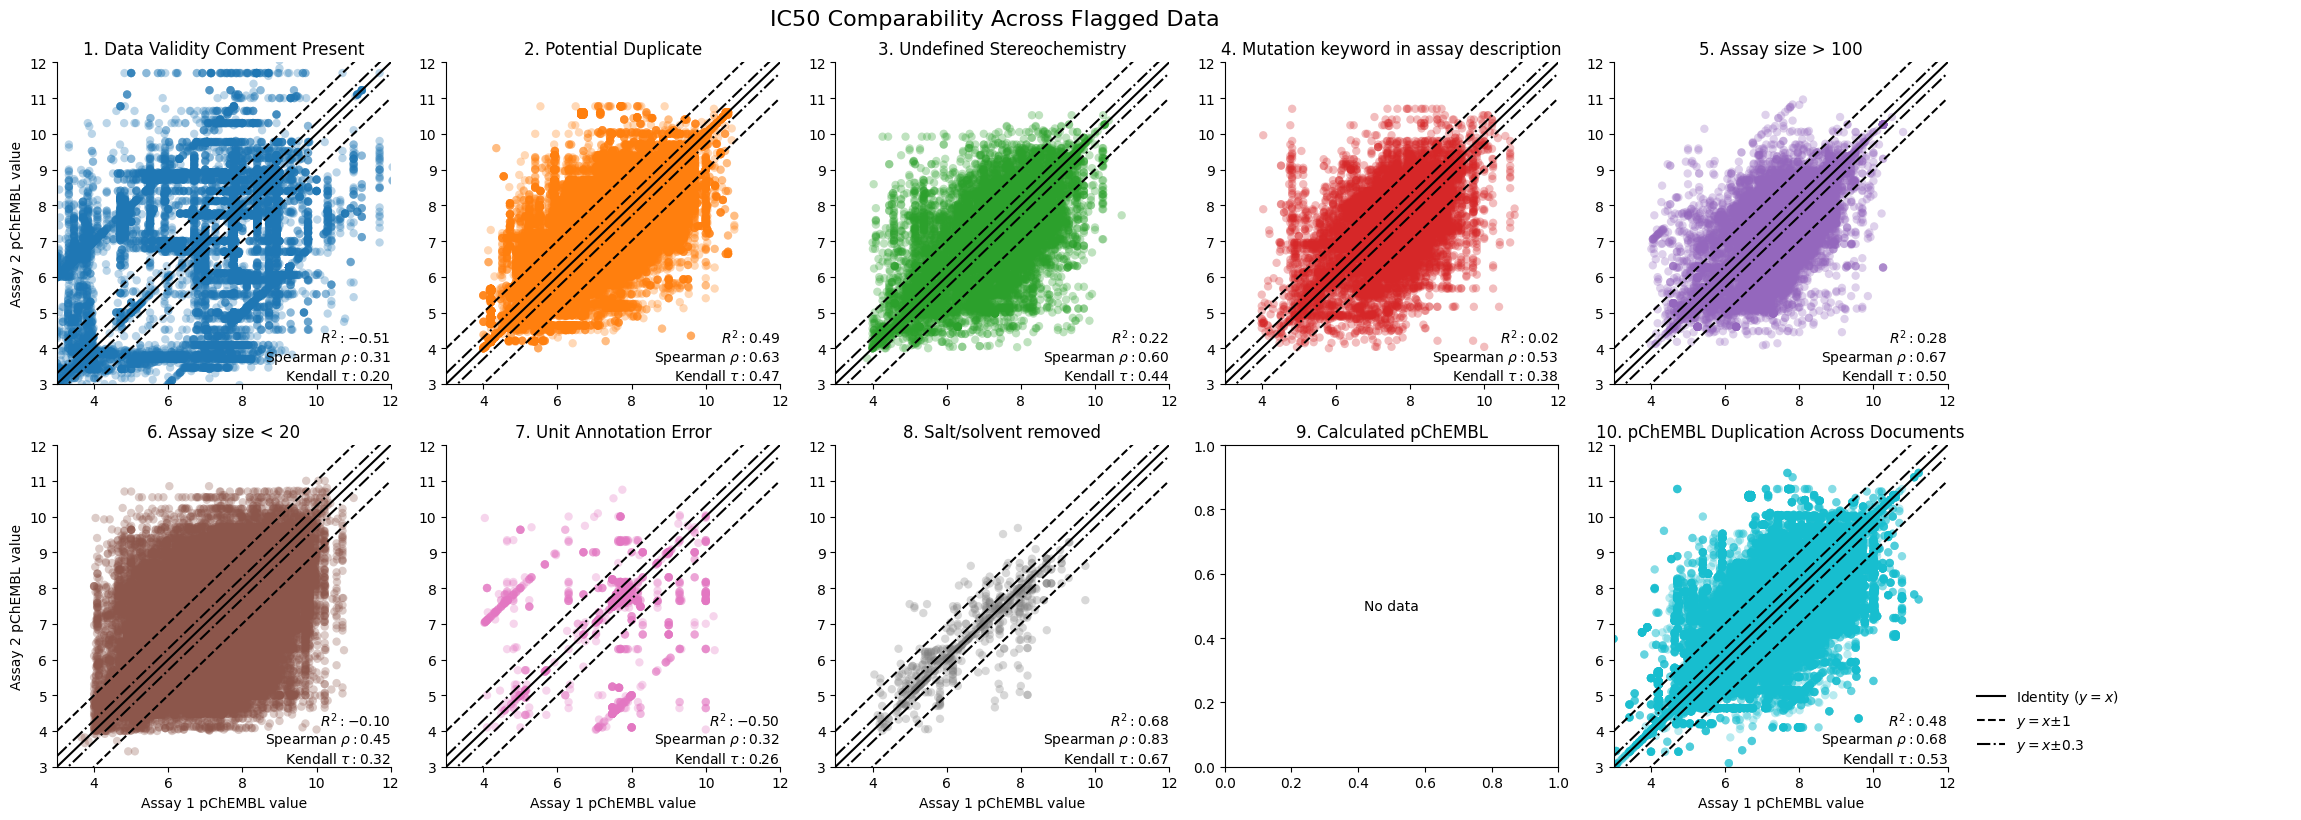

In [12]:
# Use the multi-panel plotting function from analysis module
fig, axs = plot_multi_panel_comparability(
    exploded_subset, all_comments, title="IC50 Comparability Across Flagged Data", figsize=(20, 8), ncols=5
)

In [13]:
# (
#     subset.processing_comment.apply(lambda x: x.split("|"))
#     .explode()
#     .apply(lambda x: x.split(" & "))
#     .explode()
# ).value_counts()

In [14]:
# (
#     subset.dropping_comment.apply(lambda x: x.split("|")).explode().apply(lambda x: x.split(" & ")).explode()
# ).value_counts()

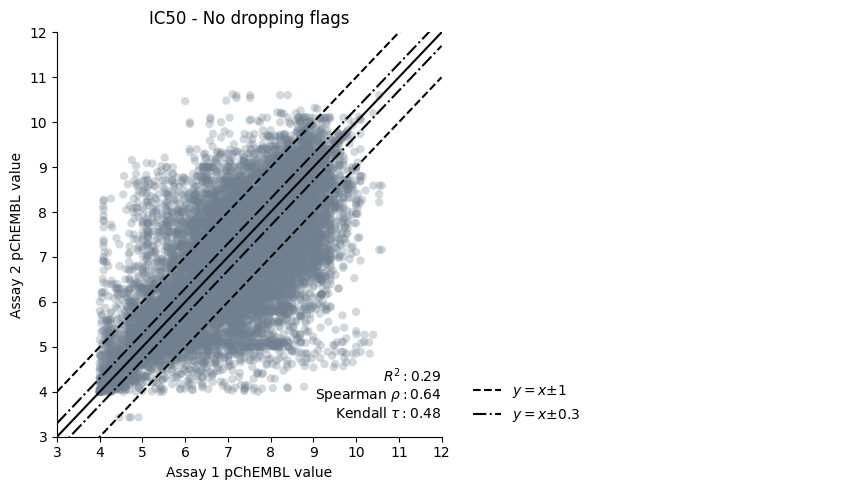

In [15]:
# Plot clean IC50 data (no dropping flags, excluding calculated pChEMBL)
rm_process_obs = ProcessingComment.CALCULATED_PCHEMBL.value

subset_clean = exploded_subset.query(
    'dropping_comment == "" & ~processing_comment.str.contains(@rm_process_obs, regex=True)'
)
fig, ax = plot_subset(subset_clean, title="IC50 - No dropping flags")
fig.savefig("IC50_allFiltered.png", dpi=300, bbox_inches="tight", transparent=True)

# Ki overlap

In [16]:
df_ki = pd.read_csv("curated_data/curated-Ki-NoAssayOverlap.csv", engine="pyarrow")
subset_ki = df_ki.query('processed_smiles.str.contains("|", regex=False)').assign(
    repeat=lambda x: range(len(x))
)
subset_ki.shape

(17874, 37)

In [17]:
df_ki.data_processing_comment.apply(
    lambda x: x.split("|") if isinstance(x, str) else []
).explode().value_counts()

data_processing_comment
                                                                                    26674
pChEMBL Duplication Across Documents                                                24923
Salt/solvent removed                                                                 5715
Calculated pChEMBL                                                                   1155
Calculated pChEMBL & pChEMBL Duplication Across Documents                             511
Salt/solvent removed & pChEMBL Duplication Across Documents                           415
Calculated pChEMBL & Salt/solvent removed & pChEMBL Duplication Across Documents      381
Calculated pChEMBL & Salt/solvent removed                                             105
Name: count, dtype: int64

In [18]:
(
    subset_ki.data_dropping_comment.fillna("")
    .apply(lambda x: x.split("|"))
    .explode()
    .apply(lambda x: x.split(" & "))
    .explode()
).value_counts()

data_dropping_comment
Assay size < 20                          19498
Potential Duplicate                      18199
                                         15185
Undefined Stereochemistry                 8888
Assay size > 100                          6458
Data Validity Comment Present             1660
Unit Annotation Error                      874
Mutation keyword in assay description      773
Name: count, dtype: int64

In [19]:
# Explode Ki data for pairwise assay comparisons
exploded_subset_ki = explode_assay_comparability(subset_ki)

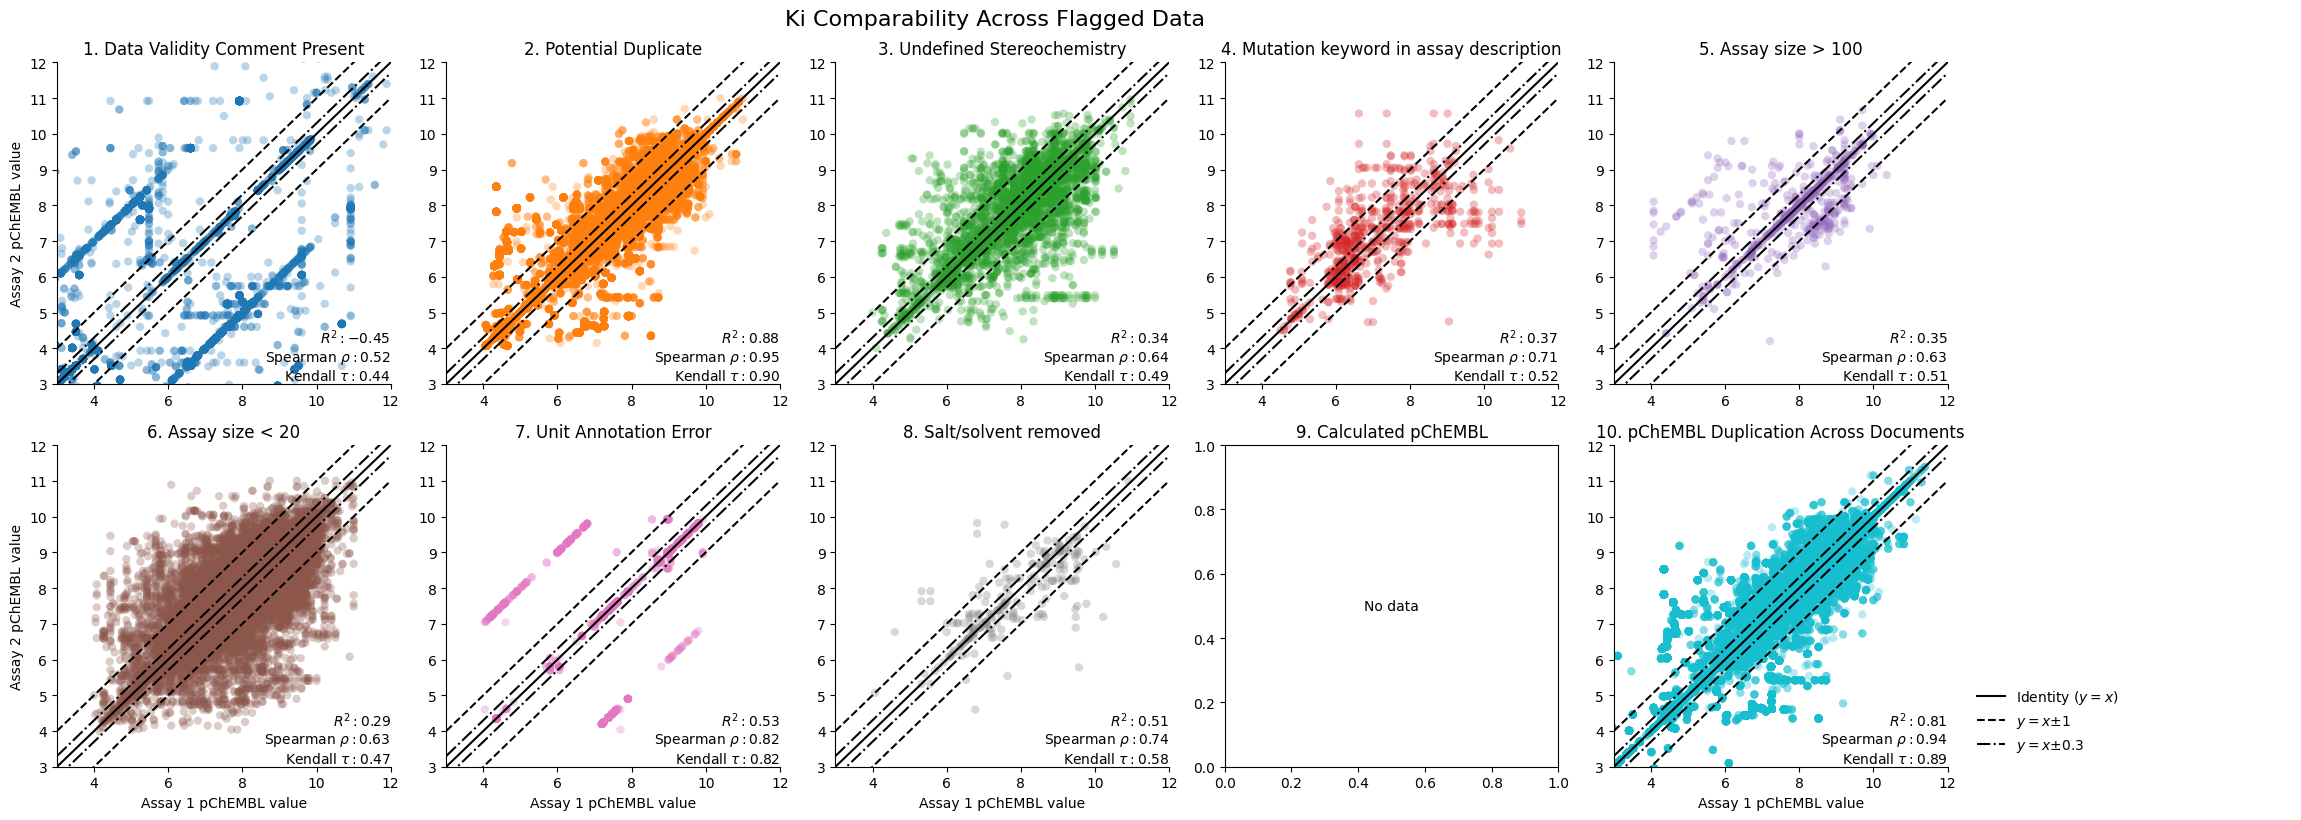

In [20]:
# Use the multi-panel plotting function for Ki data
fig, axs = plot_multi_panel_comparability(
    exploded_subset_ki, all_comments, title="Ki Comparability Across Flagged Data", figsize=(20, 8), ncols=5
)

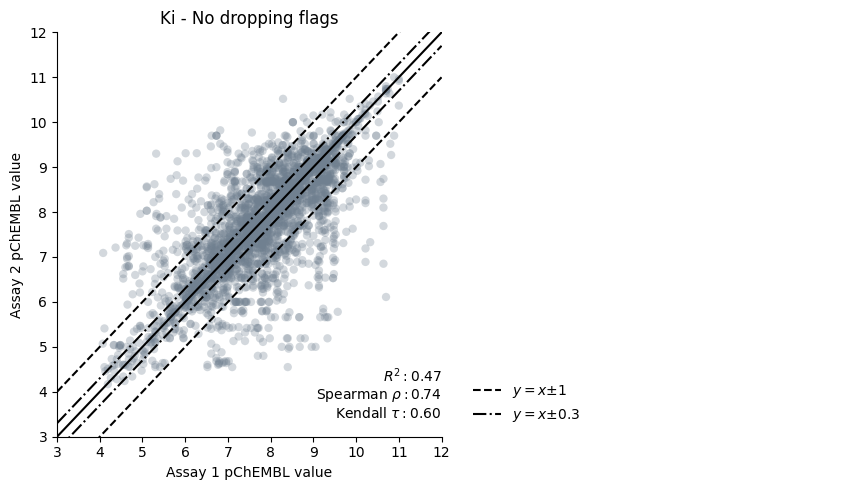

In [21]:
# Plot clean Ki data (no dropping flags, excluding calculated pChEMBL)
rm_process_obs = ProcessingComment.CALCULATED_PCHEMBL.value

subset_ki_clean = exploded_subset_ki.query(
    'dropping_comment == "" & ~processing_comment.str.contains(@rm_process_obs, regex=True)'
)
fig, ax = plot_subset(subset_ki_clean, title="Ki - No dropping flags")
fig.savefig("Ki_allFiltered.png", dpi=300, bbox_inches="tight", transparent=True)